In [1]:
import pandas as pd
import sqlite3
import numpy as np
from sklearn.preprocessing import StandardScaler

print("1. Loading data from SQLite...")
conn = sqlite3.connect('../data/processed/lending_club.db')
df = pd.read_sql_query("SELECT * FROM loans", conn)
conn.close()

# ---------------------------------------------------------
print("\n2. Handling Missing Values...")
print("--- Missing values BEFORE treatment ---")
print(df.isnull().sum()[df.isnull().sum() > 0]) # Show only columns with missing data

# Fill numeric missing values with the Median (robust against outliers)
numeric_cols = ['annual_inc', 'dti', 'open_acc', 'total_acc', 'pub_rec']
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical missing values with a placeholder
df['emp_length'] = df['emp_length'].fillna('Unknown')

print("\n--- Missing values AFTER treatment ---")
print(df.isnull().sum().sum(), "total missing values remaining.")

# ---------------------------------------------------------
print("\n3. Creating Engineered Features...")
# Feature A: Loan-to-Income Ratio (How big is the loan compared to their salary?)
# We add +1 to annual_inc to prevent "Division by Zero" errors
df['loan_to_income_ratio'] = df['loan_amnt'] / (df['annual_inc'] + 1)

# Feature B: Active Credit Ratio (How much of their available credit are they using actively?)
df['active_credit_ratio'] = df['open_acc'] / (df['total_acc'] + 1)

# Feature C: Clean Employment Length (Convert "10+ years" text into the number 10)
df['emp_length_num'] = df['emp_length'].str.extract(r'(\d+)').astype(float)
df['emp_length_num'] = df['emp_length_num'].fillna(0) # "Unknown" or "< 1 year" becomes 0

# ---------------------------------------------------------
print("\n4. Encoding Categorical Features...")
# A. Label Encode Ordinal Data (Grade: A is best/1, G is worst/7)
grade_mapping = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
df['grade_encoded'] = df['grade'].map(grade_mapping)

# B. Clean 'term' text (Convert " 36 months" to just the integer 36)
df['term_num'] = df['term'].str.extract(r'(\d+)').astype(int)

# C. One-Hot Encode Nominal Data (Purpose, Home Ownership)
# drop_first=True prevents the "Dummy Variable Trap" (multicollinearity)
df = pd.get_dummies(df, columns=['purpose', 'home_ownership'], drop_first=True)

# Drop the old text columns that the ML model can't read
columns_to_drop = ['grade', 'sub_grade', 'emp_length', 'term']
df = df.drop(columns=columns_to_drop)

# ---------------------------------------------------------
print("\n5. Scaling Numerical Features...")
# Separate Features (X) from Target (y)
X = df.drop('target', axis=1)
y = df['target']

# Initialize Scaler and fit_transform the data
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# ---------------------------------------------------------
print("\n6. Final Dataset Overview...")
print(f"Shape of X (Features): {X_scaled.shape}")
print(f"Shape of y (Target): {y.shape}")

print("\n7. THE CLASS IMBALANCE PROBLEM:")
imbalance = y.value_counts()
print(f"Paid Off (0):  {imbalance[0]} loans ({round(imbalance[0]/len(y)*100, 1)}%)")
print(f"Defaulted (1): {imbalance[1]} loans ({round(imbalance[1]/len(y)*100, 1)}%)")

print("\nPhase 4 Complete! Data is now mathematically ready for Machine Learning.")


1. Loading data from SQLite...

2. Handling Missing Values...
--- Missing values BEFORE treatment ---
emp_length    23471
dti              54
dtype: int64

--- Missing values AFTER treatment ---
0 total missing values remaining.

3. Creating Engineered Features...

4. Encoding Categorical Features...

5. Scaling Numerical Features...

6. Final Dataset Overview...
Shape of X (Features): (391164, 28)
Shape of y (Target): (391164,)

7. THE CLASS IMBALANCE PROBLEM:
Paid Off (0):  312340 loans (79.8%)
Defaulted (1): 78824 loans (20.2%)

Phase 4 Complete! Data is now mathematically ready for Machine Learning.


In [5]:
import sys
!{sys.executable} -m pip install imbalanced-learn

  Using cached imbalanced_learn-0.14.1-py3-none-any.whl.metadata (8.9 kB)
  Using cached sklearn_compat-0.1.5-py3-none-any.whl.metadata (20 kB)
Using cached imbalanced_learn-0.14.1-py3-none-any.whl (235 kB)
Using cached sklearn_compat-0.1.5-py3-none-any.whl (20 kB)

   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]


In [2]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

print("1. Splitting data into Train and Test sets (80/20)...")
# We use stratify=y to ensure the 80/20 default ratio is maintained in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y
)

print("\n2. Original Training Set Distribution (Imbalanced):")
print(y_train.value_counts())

print("\n3. Applying SMOTE to the Training Data ONLY...")
# Initialize SMOTE with a random seed for reproducibility
smote = SMOTE(random_state=42)

# fit_resample generates new synthetic data for the minority class (1s)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\n4. New Training Set Distribution (After SMOTE):")
print(y_train_smote.value_counts())

print("\n5. Test Set Distribution (Left Imbalanced on purpose):")
print(y_test.value_counts())

print("\n6. Final Array Shapes Verification:")
print(f"X_train_smote: {X_train_smote.shape}")
print(f"y_train_smote: {y_train_smote.shape}")
print(f"X_test:        {X_test.shape}")
print(f"y_test:        {y_test.shape}")

print("\nPhase 5 Complete! Ready for Model Training.")

1. Splitting data into Train and Test sets (80/20)...

2. Original Training Set Distribution (Imbalanced):
target
0    249872
1     63059
Name: count, dtype: int64

3. Applying SMOTE to the Training Data ONLY...

4. New Training Set Distribution (After SMOTE):
target
0    249872
1    249872
Name: count, dtype: int64

5. Test Set Distribution (Left Imbalanced on purpose):
target
0    62468
1    15765
Name: count, dtype: int64

6. Final Array Shapes Verification:
X_train_smote: (499744, 28)
y_train_smote: (499744,)
X_test:        (78233, 28)
y_test:        (78233,)

Phase 5 Complete! Ready for Model Training.


In [4]:
import sys
!{sys.executable} -m pip install xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)


Starting Model Training... (Please wait 3-5 minutes)

========== Training Logistic Regression ==========


C:\Users\KAPOOR\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Accuracy: 0.6800
AUC-ROC:  0.7241

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.69      0.78     62468
           1       0.34      0.63      0.44     15765

    accuracy                           0.68     78233
   macro avg       0.61      0.66      0.61     78233
weighted avg       0.77      0.68      0.71     78233

Confusion Matrix:
[[43198 19270]
 [ 5764 10001]]


========== Training Random Forest ==========
Accuracy: 0.7748
AUC-ROC:  0.7036

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86     62468
           1       0.42      0.31      0.35     15765

    accuracy                           0.77     78233
   macro avg       0.63      0.60      0.61     78233
weighted avg       0.75      0.77      0.76     78233

Confusion Matrix:
[[55781  6687]
 [10930  4835]]


========== Training XGBoost ==========


C:\Users\KAPOOR\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:35:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.7925
AUC-ROC:  0.7105

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.94      0.88     62468
           1       0.47      0.20      0.28     15765

    accuracy                           0.79     78233
   macro avg       0.64      0.57      0.58     78233
weighted avg       0.75      0.79      0.76     78233

Confusion Matrix:
[[58811  3657]
 [12577  3188]]




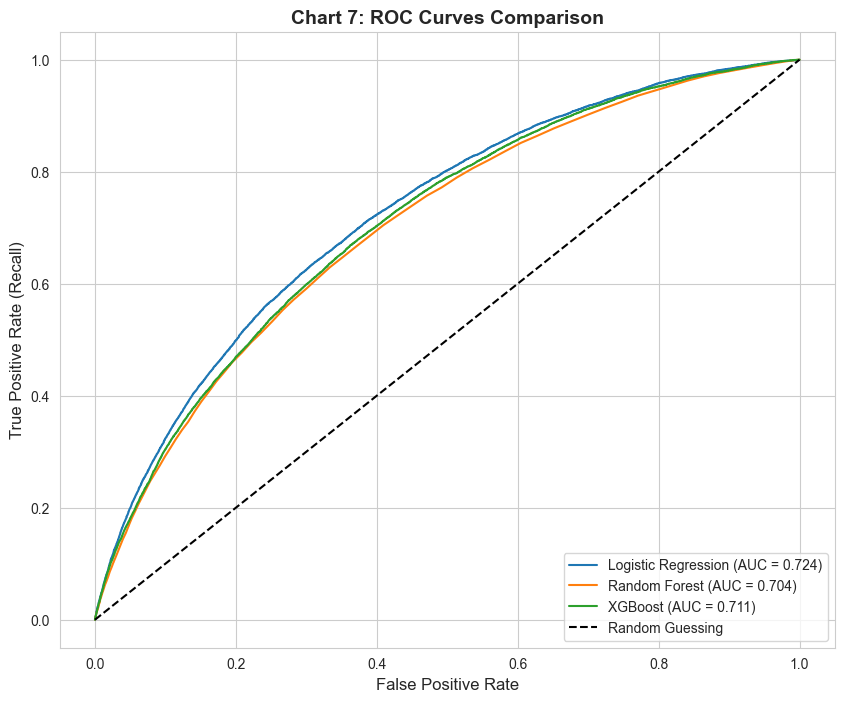


========== FINAL MODEL COMPARISON ==========
                     AUC-ROC  F1 Score  Precision  Recall
Model                                                    
Logistic Regression   0.7241    0.4441     0.3417  0.6344
Random Forest         0.7036    0.3544     0.4196  0.3067
XGBoost               0.7105    0.2820     0.4657  0.2022

Phase 6 Complete! We have evaluated all models.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix, roc_curve

# 1. Initialize our three models
# n_jobs=-1 tells your computer to use ALL available CPU cores to train faster
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1)
}

# List to hold our final metrics for the comparison table
results_list = []

# Prepare the ROC Curve chart
plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")

print("Starting Model Training... (Please wait 3-5 minutes)\n")

# 2. Loop through each model, train it, and evaluate it
for name, model in models.items():
    print(f"========== Training {name} ==========")
    
    # TRAIN the model on the balanced SMOTE data
    model.fit(X_train_smote, y_train_smote)
    
    # PREDICT on the unseen, imbalanced test data
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] # Get probabilities for class 1 (Default)
    
    # Calculate Metrics
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    print(f"Accuracy: {acc:.4f}")
    print(f"AUC-ROC:  {auc:.4f}")
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    print("Confusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)
    print("\n" + "="*40 + "\n")
    
    # Extract specific metrics for class 1 (Defaulters) for our comparison table
    report_dict = classification_report(y_test, y_pred, output_dict=True)
    results_list.append({
        "Model": name,
        "AUC-ROC": round(auc, 4),
        "F1 Score": round(report_dict['1']['f1-score'], 4),
        "Precision": round(report_dict['1']['precision'], 4),
        "Recall": round(report_dict['1']['recall'], 4)
    })
    
    # Add this model's curve to our ROC chart
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

# 3. Finalize and display the ROC Curve plot
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.title('Chart 7: ROC Curves Comparison', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.legend(loc='lower right')
plt.savefig('images/chart7_roc_comparison.png', bbox_inches='tight')
plt.show()

# 4. Display the Final Comparison Table
print("\n========== FINAL MODEL COMPARISON ==========")
comparison_df = pd.DataFrame(results_list).set_index("Model")
print(comparison_df.to_string())

print("\nPhase 6 Complete! We have evaluated all models.")

1. Setting up GridSearchCV for XGBoost...
2. Running Grid Search (WARNING: This may take 20-45 minutes. Grab a coffee! ☕)

Fitting 5 folds for each of 54 candidates, totalling 270 fits


C:\Users\KAPOOR\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:40:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



3. Best Parameters Found!
{'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 300, 'subsample': 1.0}

4. Training Final Model with Best Parameters on FULL Training Data...


C:\Users\KAPOOR\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:40:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



5. Evaluating Final Model on Test Data...

========== FINAL AUC-ROC: 0.7149 ==========
(Memorize this number for your interviews!)

Final Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.95      0.88     62468
           1       0.48      0.19      0.27     15765

    accuracy                           0.80     78233
   macro avg       0.65      0.57      0.58     78233
weighted avg       0.75      0.80      0.76     78233

6. Generating Confusion Matrix Heatmap...


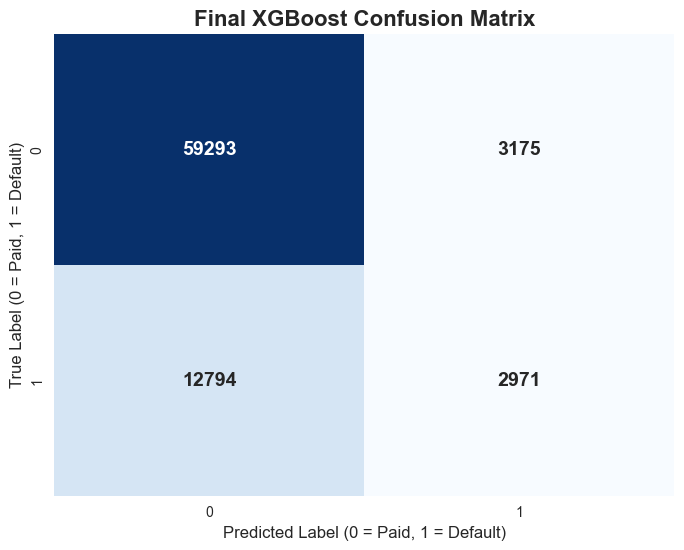

7. Saving the Final Model...
Phase 7 Complete! Model successfully saved as '../models/credit_risk_model.pkl'.


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

print("1. Setting up GridSearchCV for XGBoost...")

# Define the exact parameter grid requested
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

# Initialize the base model
xgb_base = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1)

# Initialize GridSearchCV
# scoring='roc_auc' tells it to find the parameters that maximize the AUC-ROC score
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='roc_auc', 
    cv=5,
    verbose=2, # Prints progress so you don't think it froze
    n_jobs=-1  # Uses all CPU cores
)

print("2. Running Grid Search (WARNING: This may take 20-45 minutes. Grab a coffee! ☕)\n")
# Note: To save time, we are running the search on a 25% random sample of the training data.
# The final model will still be trained on 100% of the data.
sample_size = int(len(X_train_smote) * 0.25)
X_train_sample = X_train_smote.sample(n=sample_size, random_state=42)
y_train_sample = y_train_smote.sample(n=sample_size, random_state=42)

grid_search.fit(X_train_sample, y_train_sample)

print("\n3. Best Parameters Found!")
print(grid_search.best_params_)

print("\n4. Training Final Model with Best Parameters on FULL Training Data...")
# Extract the absolute best model from the Grid Search
best_xgb_model = grid_search.best_estimator_

# Train it on the FULL SMOTE dataset
best_xgb_model.fit(X_train_smote, y_train_smote)

print("\n5. Evaluating Final Model on Test Data...")
y_pred_final = best_xgb_model.predict(X_test)
y_prob_final = best_xgb_model.predict_proba(X_test)[:, 1]

final_auc = roc_auc_score(y_test, y_prob_final)
print(f"\n========== FINAL AUC-ROC: {final_auc:.4f} ==========")
print("(Memorize this number for your interviews!)\n")

print("Final Classification Report:")
print(classification_report(y_test, y_pred_final))

print("6. Generating Confusion Matrix Heatmap...")
plt.figure(figsize=(8, 6))
cm_final = confusion_matrix(y_test, y_pred_final)
# Draw a beautiful heatmap for the confusion matrix
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues', cbar=False, 
            annot_kws={'size': 14, 'weight': 'bold'})
plt.title('Final XGBoost Confusion Matrix', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label (0 = Paid, 1 = Default)', fontsize=12)
plt.ylabel('True Label (0 = Paid, 1 = Default)', fontsize=12)
plt.savefig('images/final_confusion_matrix.png', bbox_inches='tight')
plt.show()

print("7. Saving the Final Model...")
# Save the model to our 'models' folder
joblib.dump(best_xgb_model, '../models/credit_risk_model.pkl')
print("Phase 7 Complete! Model successfully saved as '../models/credit_risk_model.pkl'.")

In [6]:
import sys
!{sys.executable} -m pip install shap

  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
   ---------------------------------------- 0.0/556.1 kB ? eta -:--:--
   ---------------------------------------- 556.1/556.1 kB 3.1 MB/s  0:00:00
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------- ----------------------------- 10.5/38.1 MB 50.1 MB/s eta 0:00:01
   ---------------------- ----------------- 21.2/38.1 MB 53.6 MB/s eta 0:00:01
   -------------------------------- ------- 31.5/38.1 MB 51.1 MB/s eta 0:00:01
   ---------------------------------------  38.0/38.1 MB 48.3 MB/s eta 0:00:01
   ---------------------------------------- 38.1/38.1 MB 42.5 MB/s  0:00:00
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 2.8/2.8 MB 53.0 MB/s  0:00:00

   -----

C:\Users\KAPOOR\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


1. Initializing SHAP Explainer...
2. Generating Chart 1: SHAP Summary Plot (Beeswarm)...


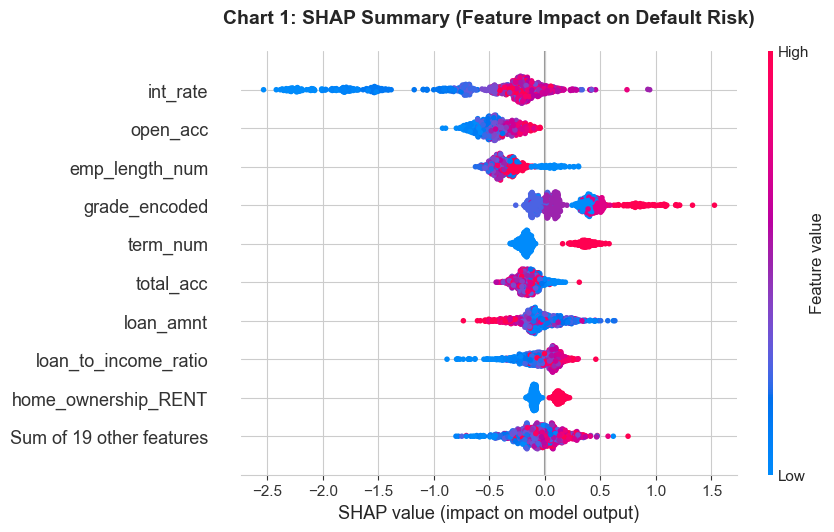

3. Generating Chart 2: Feature Importance (Bar Plot)...


<Figure size 640x480 with 0 Axes>

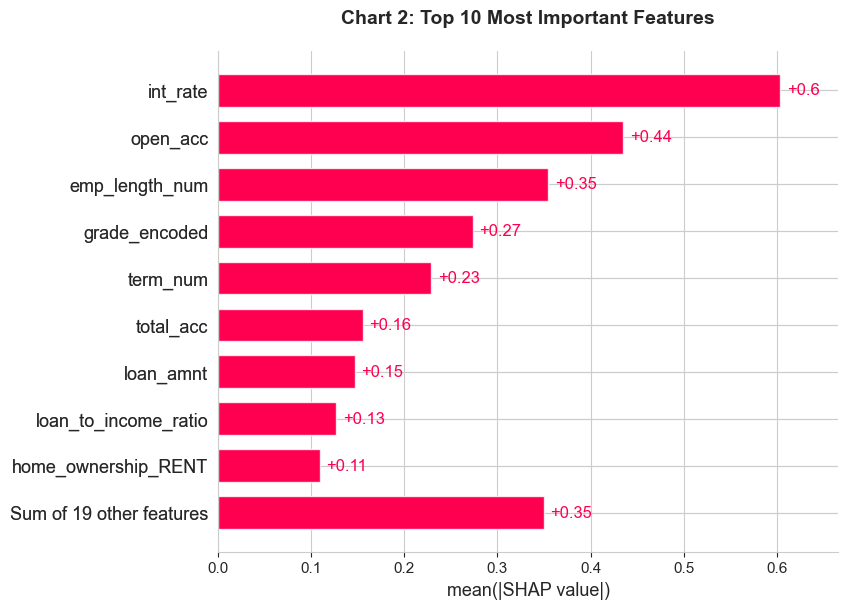

4. Generating Chart 3: Individual Applicant (Waterfall Plot)...


<Figure size 640x480 with 0 Axes>

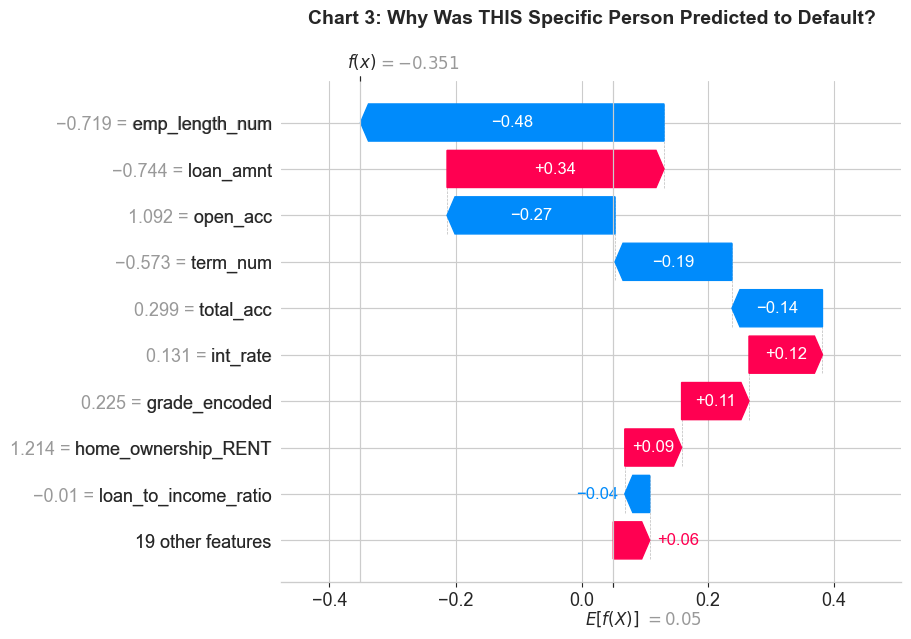

5. Generating Chart 4: Dependence Plot for Interest Rate...


<Figure size 640x480 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

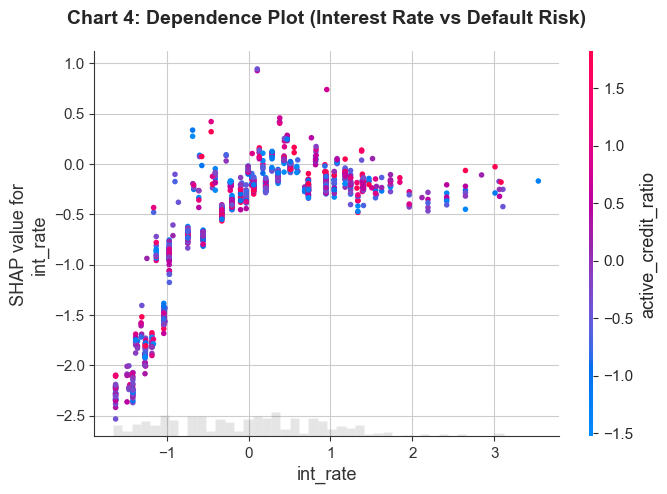


Phase 8 Complete! All 4 SHAP charts saved successfully in the 'images' folder.


<Figure size 640x480 with 0 Axes>

In [5]:
import shap
import matplotlib.pyplot as plt
import pandas as pd

print("1. Initializing SHAP Explainer...")
# SHAP calculates every possible permutation of features, which is slow.
# For visualizing, a random sample of 1,000 test rows is an industry standard best practice.
X_test_sample = X_test.sample(n=1000, random_state=42)

# Create the TreeExplainer using our tuned model from Phase 7
explainer = shap.TreeExplainer(best_xgb_model)

# Calculate SHAP values for our sample
shap_values = explainer(X_test_sample)

# ---------------------------------------------------------
print("2. Generating Chart 1: SHAP Summary Plot (Beeswarm)...")
plt.figure(figsize=(10, 6))
# beeswarm shows the spread and impact of every single data point
shap.plots.beeswarm(shap_values, show=False)
plt.title("Chart 1: SHAP Summary (Feature Impact on Default Risk)", fontsize=14, fontweight='bold', pad=20)
plt.savefig("images/shap_1_beeswarm.png", bbox_inches='tight')
plt.show()
plt.clf()

# ---------------------------------------------------------
print("3. Generating Chart 2: Feature Importance (Bar Plot)...")
plt.figure(figsize=(10, 6))
# bar plot averages the absolute SHAP values to give a clean Top 10 ranking
shap.plots.bar(shap_values, show=False)
plt.title("Chart 2: Top 10 Most Important Features", fontsize=14, fontweight='bold', pad=20)
plt.savefig("images/shap_2_bar.png", bbox_inches='tight')
plt.show()
plt.clf()

# ---------------------------------------------------------
print("4. Generating Chart 3: Individual Applicant (Waterfall Plot)...")
plt.figure(figsize=(10, 6))
# We take index [0], meaning we are looking at the very first applicant in our 1000-person sample
shap.plots.waterfall(shap_values[0], show=False)
plt.title("Chart 3: Why Was THIS Specific Person Predicted to Default?", fontsize=14, fontweight='bold', pad=20)
plt.savefig("images/shap_3_waterfall.png", bbox_inches='tight')
plt.show()
plt.clf()

# ---------------------------------------------------------
print("5. Generating Chart 4: Dependence Plot for Interest Rate...")
plt.figure(figsize=(10, 6))
# Scatter plot shows how 'int_rate' directly correlates with SHAP value (risk)
shap.plots.scatter(shap_values[:, "int_rate"], color=shap_values, show=False)
plt.title("Chart 4: Dependence Plot (Interest Rate vs Default Risk)", fontsize=14, fontweight='bold', pad=20)
plt.savefig("images/shap_4_dependence.png", bbox_inches='tight')
plt.show()
plt.clf()

print("\nPhase 8 Complete! All 4 SHAP charts saved successfully in the 'images' folder.")